## Imports

In [199]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## DagsHub/MLflow Initialization

In [200]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [201]:
import dagshub
import mlflow
import mlflow.sklearn
import skops.io as sio
from mlflow.tracking import MlflowClient

dagshub.init(repo_owner='adzid23', repo_name='Freeuni_ML_House_Prices', mlflow=True)

Initialized MLflow to track repo "adzid23/Freeuni_ML_House_Prices"

Repository adzid23/Freeuni_ML_House_Prices initialized!

# Exploratory Data Analysis (EDA)

In [202]:
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (1460, 81)
Test shape:  (1459, 80)


In [203]:
X = train_df.drop(columns=['SalePrice'])
y = train_df['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Val size:   {X_val.shape}")

Train size: (1168, 80)
Val size:   (292, 80)


In [204]:
print(X_train.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1168.000000  1168.000000   951.000000    1168.000000  1168.000000   
mean    730.904966    56.849315    70.343849   10689.642123     6.121575   
std     425.369088    42.531862    24.897021   10759.366198     1.367619   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     360.750000    20.000000    59.000000    7587.250000     5.000000   
50%     732.500000    50.000000    70.000000    9600.000000     6.000000   
75%    1101.750000    70.000000    80.000000   11700.000000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1168.000000  1168.000000   1168.000000  1162.000000  1168.000000  ...   
mean      5.584760  1970.965753   1984.897260   103.771945   446.023973  ...   
std       1.116062    30.675495     20.733955   173.032238   459.070977  ..

In [205]:
print(X_train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      217
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 80, dtype: int64


In [206]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCond

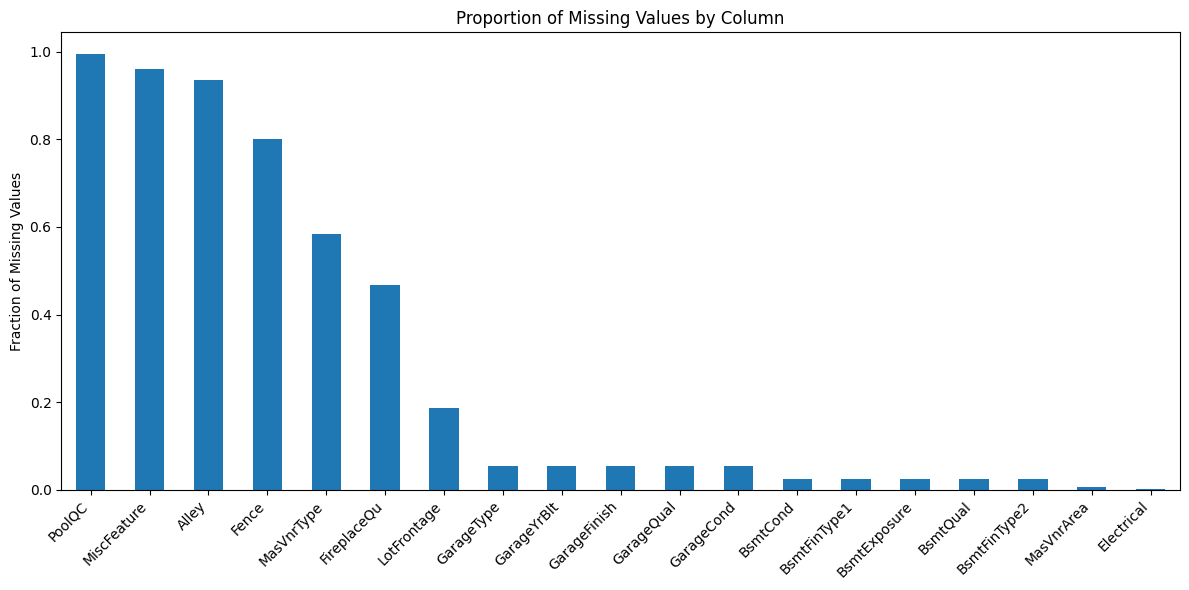

In [207]:
# Missing value visualisation
null_ratio = X_train.isna().sum() / X_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [208]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns   ({len(num_cols)}): {num_cols}")

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns   (37): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'Garag

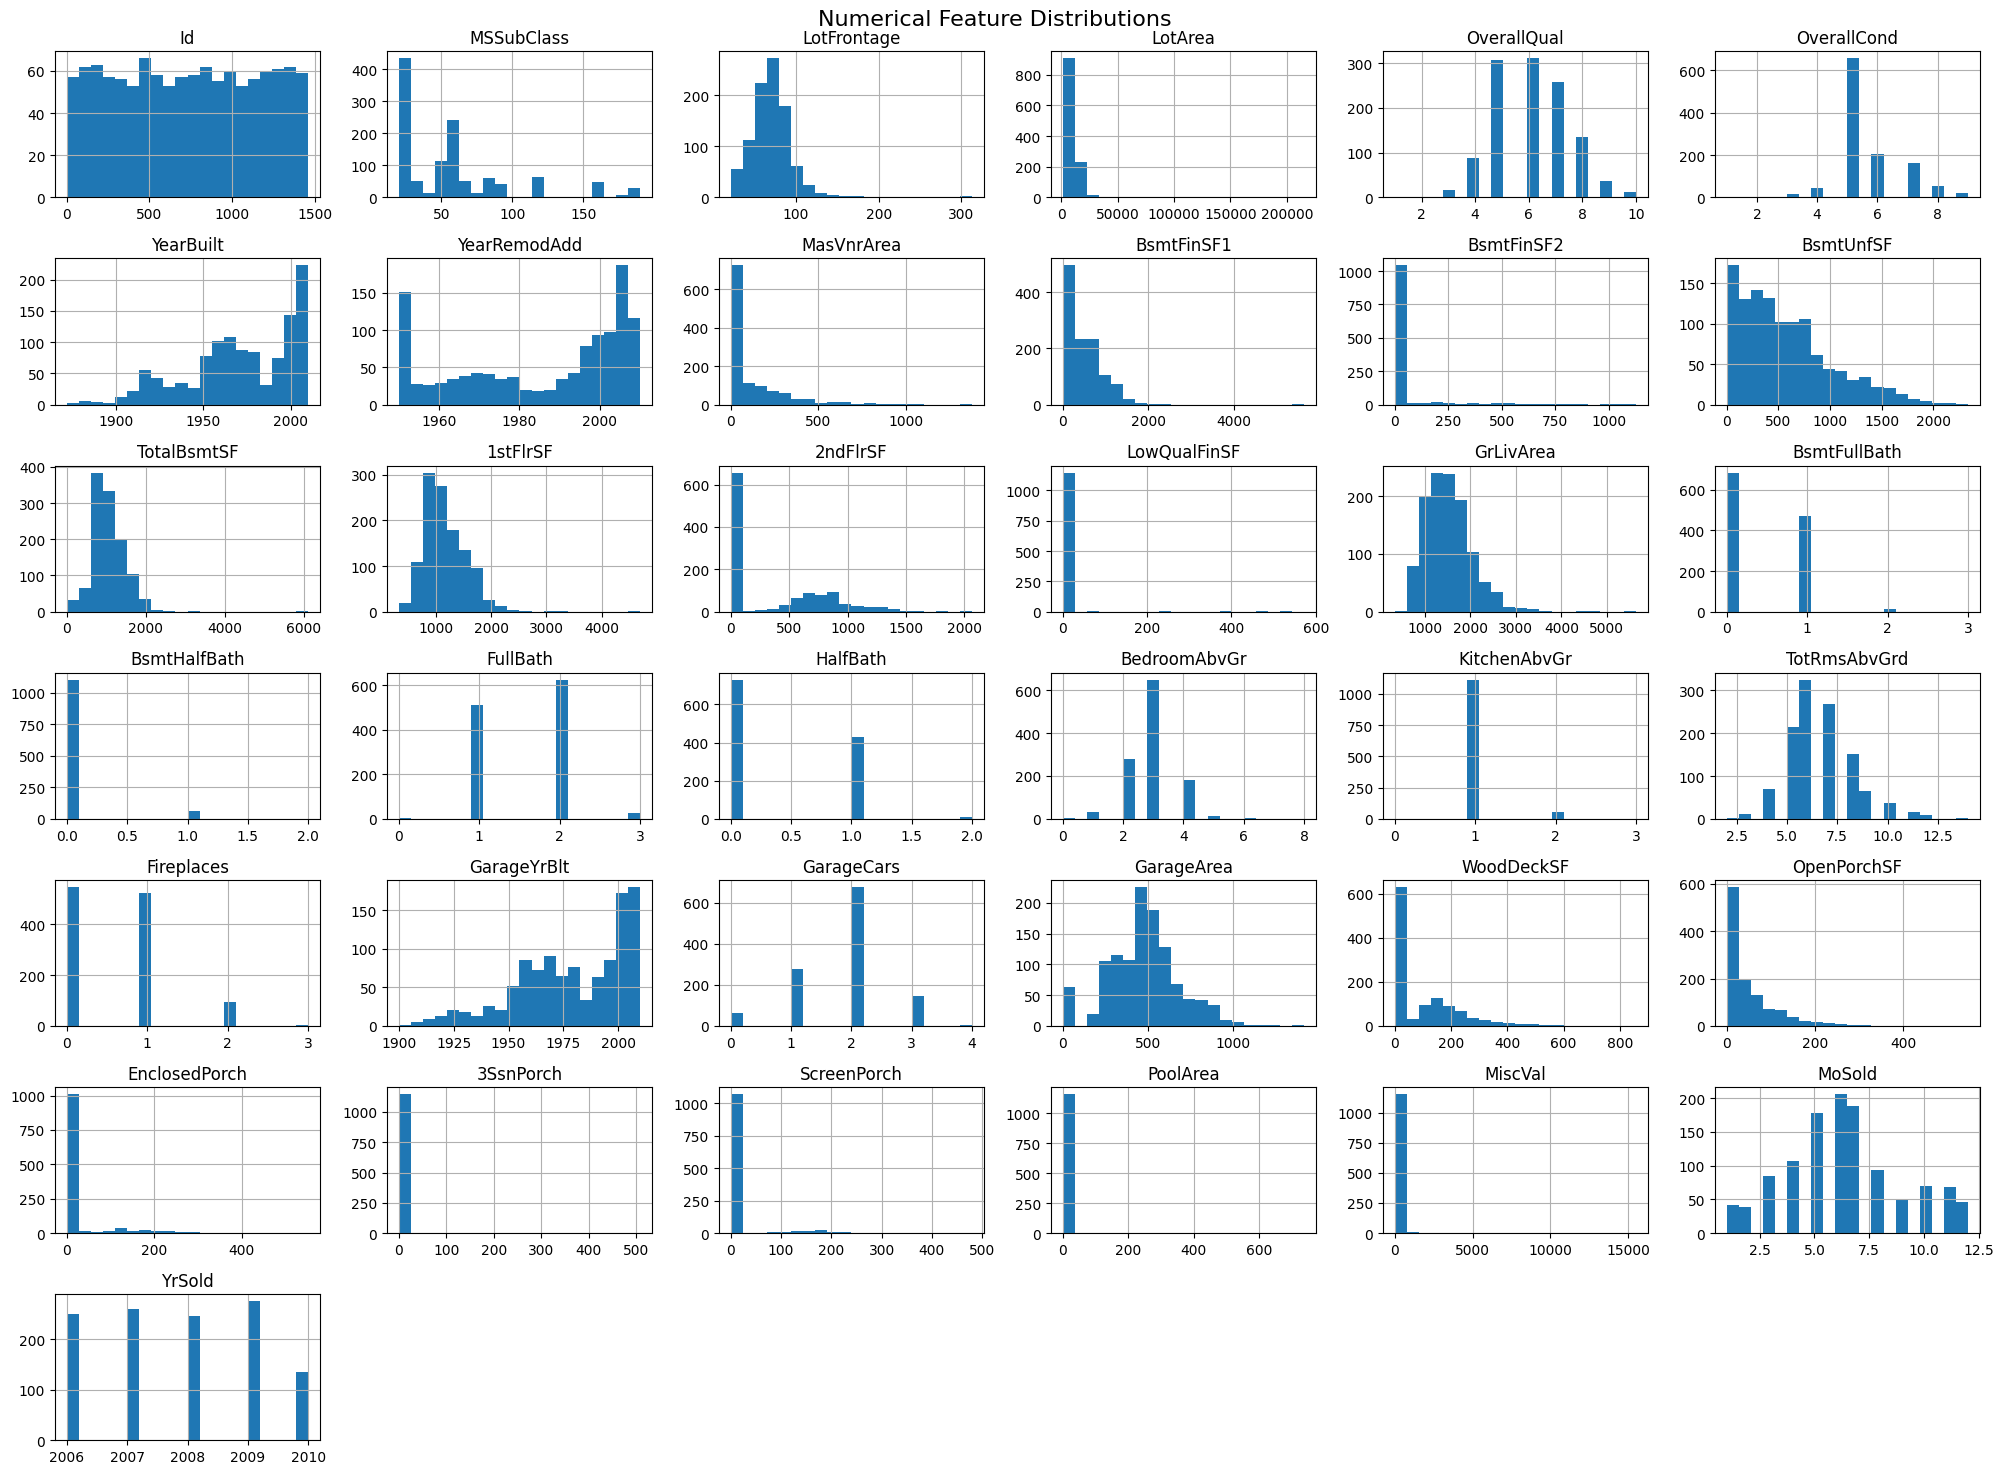

In [209]:
# Distribution of numerical features
X_train[num_cols].hist(bins=20, figsize=(20, 15))
plt.suptitle('Numerical Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

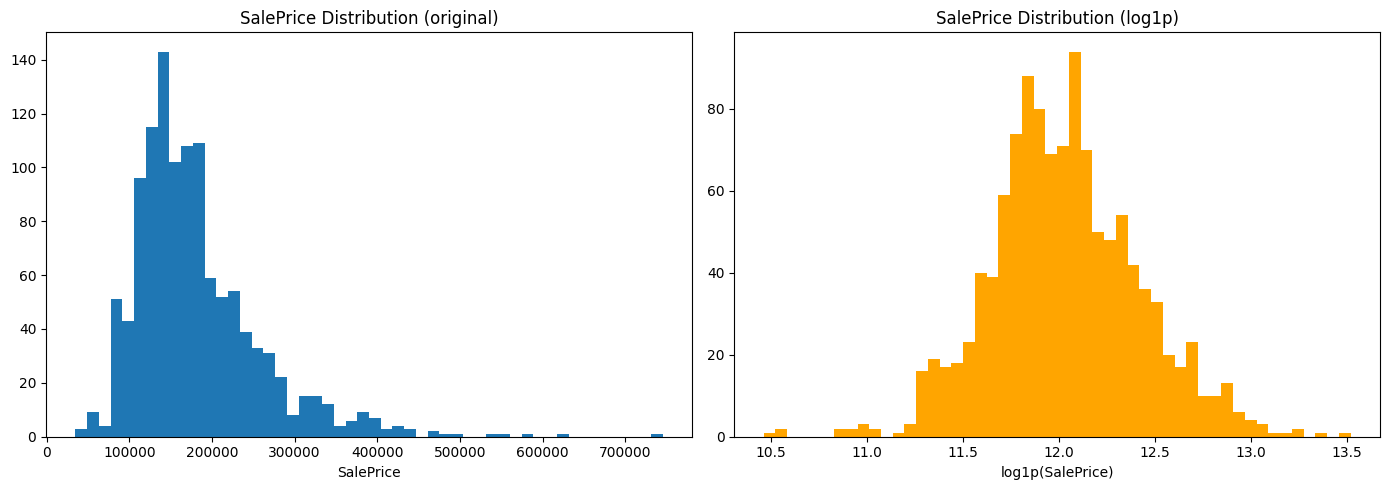

In [210]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50)
axes[0].set_title('SalePrice Distribution (original)')
axes[0].set_xlabel('SalePrice')

axes[1].hist(np.log1p(y_train), bins=50, color='orange')
axes[1].set_title('SalePrice Distribution (log1p)')
axes[1].set_xlabel('log1p(SalePrice)')

plt.tight_layout()
plt.show()

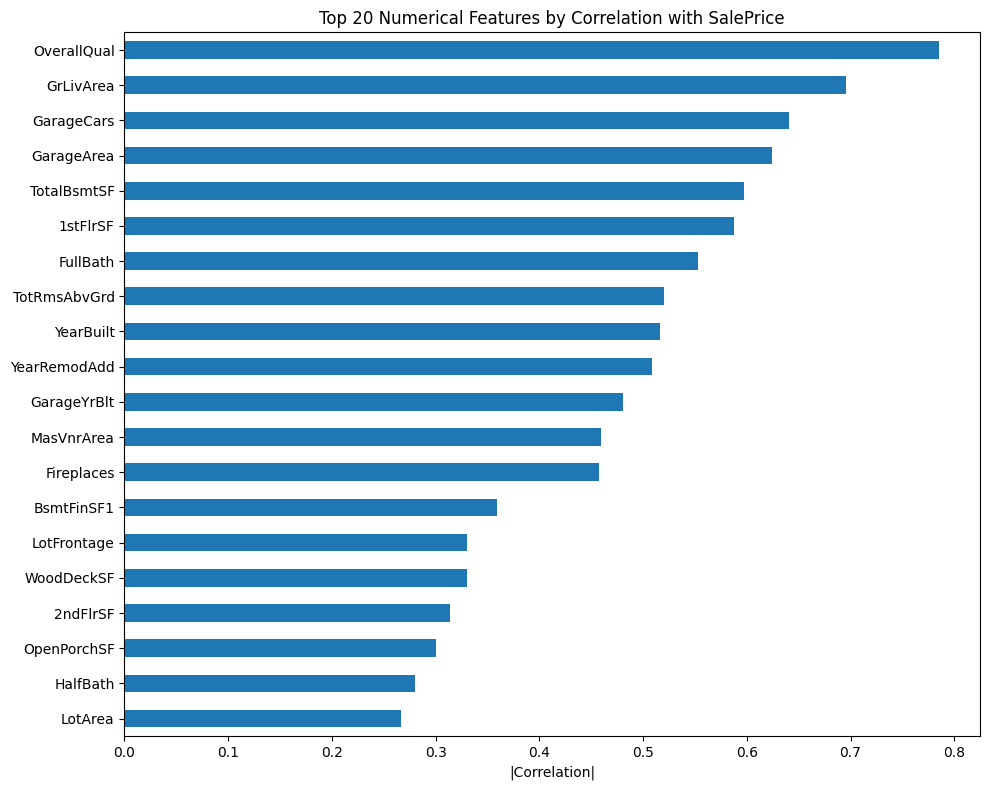

In [211]:
# Correlation of numerical features with SalePrice
train_plot = X_train.copy()
train_plot['SalePrice'] = y_train.values

corr_with_target = train_plot[num_cols + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_with_target.head(20).plot(kind='barh')
plt.title('Top 20 Numerical Features by Correlation with SalePrice')
plt.xlabel('|Correlation|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Data Cleaning

In [212]:
# Columns where NaN means 'None/No feature' per data description
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'MasVnrType',
]

# Columns where NaN means 0
zero_cols = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageArea', 'GarageCars']

# Columns to drop: too many NaNs or not useful
drop_cols = ['Id', 'PoolQC', 'MiscFeature', 'Alley', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2']

# Ordinal columns (ordered categories)
ordinal_cols = [
    'LotShape', 'LandContour', 'Utilities', 'LandSlope',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual',
    'FireplaceQu', 'GarageFinish', 'GarageQual', 'Fence',
    'CentralAir', 'Functional', 'PavedDrive',
]

# One-hot encoding columns (nominal categories)
ohe_cols = [
    'MSZoning', 'Street', 'Alley', 'LotConfig', 'Neighborhood',
    'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'MasVnrType', 'Foundation', 'Heating', 'Electrical',
    'GarageType', 'SaleType', 'SaleCondition',
]

# After dropping drop_cols, recalculate available ohe and ordinal cols
ohe_cols    = [c for c in ohe_cols    if c not in drop_cols]
ordinal_cols = [c for c in ordinal_cols if c not in drop_cols]

# Numerical columns (all that are not object and not dropped)
num_cols_clean = [
    c for c in X_train.columns
    if c not in drop_cols
    and c not in ohe_cols
    and c not in ordinal_cols
    and X_train[c].dtype != 'object'
]

print(f"Numerical cols:  {len(num_cols_clean)}")
print(f"Ordinal cols:    {len(ordinal_cols)}")
print(f"OHE cols:        {len(ohe_cols)}")

Numerical cols:  35
Ordinal cols:    19
OHE cols:        19


In [213]:
# Build the ColumnTransformer for cleaning + encoding

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',      num_pipeline,      num_cols_clean),
        ('ordinal',  ordinal_pipeline,  ordinal_cols),
        ('ohe',      ohe_pipeline,      ohe_cols),
        ('drop',     'drop',            drop_cols),
    ],
    remainder='drop'
)

## Feature Engineering

In [214]:
class HouseAgeAdder(BaseEstimator, TransformerMixin):
    """Adds HouseAge and HouseRemodelAge from year columns."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['HouseAge']        = X['YrSold'] - X['YearBuilt']
        X['HouseRemodelAge'] = X['YrSold'] - X['YearRemodAdd']
        return X

In [215]:
class AreaAdder(BaseEstimator, TransformerMixin):
    """Combines area columns into aggregate features."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['TotalSF']      = X['1stFlrSF'] + X['2ndFlrSF'] + X['BsmtFinSF1'] + X['BsmtFinSF2']
        X['TotalArea']    = X['GrLivArea'] + X['TotalBsmtSF']
        X['TotalPorchSF'] = (X['OpenPorchSF'] + X['3SsnPorch'] +
                             X['EnclosedPorch'] + X['ScreenPorch'] + X['WoodDeckSF'])
        return X

In [216]:
class BathAdder(BaseEstimator, TransformerMixin):
    """Combines bathroom columns into a single TotalBaths feature."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['TotalBaths'] = (X['FullBath'] + 0.5 * X['HalfBath'] +
                           X['BsmtFullBath'] + 0.5 * X['BsmtHalfBath'])
        return X

In [217]:
class ColumnNameRestorer(BaseEstimator, TransformerMixin):
    """Restores column names lost after ColumnTransformer."""
    def __init__(self, column_transformer):
        self.column_transformer = column_transformer

    def fit(self, X, y=None):
        self.feature_names_ = self.column_transformer.get_feature_names_out()
        return self

    def transform(self, X):
        return pd.DataFrame(X, columns=self.feature_names_)

## Feature Selection

In [218]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """Drops one feature from each highly-correlated pair."""
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.features_to_drop_ = None
        self.selected_features_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).reset_index(drop=True)
        corr_matrix = X.corr().abs()

        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        self.features_to_drop_ = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):
                partners = upper.index[upper[col] > self.threshold].tolist()
                for partner in partners:
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        self.features_to_drop_.add(col)
                    else:
                        self.features_to_drop_.add(partner)

        self.selected_features_ = [
            col for col in X.columns if col not in self.features_to_drop_
        ]

        print(f"CorrelationFilter dropped ({len(self.features_to_drop_)}): {self.features_to_drop_}")
        print(f"CorrelationFilter kept:   {len(self.selected_features_)} features")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features_]

In [219]:
class RFESelector(BaseEstimator, TransformerMixin):
    """Wraps sklearn RFE with a Ridge estimator for feature ranking."""
    def __init__(self, n_features_to_select=60):
        self.n_features_to_select = n_features_to_select
        self.selected_features_ = None
        self.rfe_ = None

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        self.feature_names_ = list(X.columns)

        estimator = Ridge(alpha=1.0)
        self.rfe_ = RFE(estimator=estimator, n_features_to_select=self.n_features_to_select)
        self.rfe_.fit(X, y)

        self.selected_features_ = [
            f for f, s in zip(self.feature_names_, self.rfe_.support_) if s
        ]
        print(f"RFE selected {len(self.selected_features_)} features: {self.selected_features_}")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        X.columns = self.feature_names_
        return X[self.selected_features_]

## Full Pipeline

In [220]:
preprocessing_pipeline = Pipeline([
    ('house_age',    HouseAgeAdder()),
    ('area',         AreaAdder()),
    ('baths',        BathAdder()),
    ('preprocessor', preprocessor),
    ('col_restorer', ColumnNameRestorer(preprocessor)),
    ('corr_filter',  CorrelationFilter(threshold=0.90)),
    ('rfe',          RFESelector(n_features_to_select=60)),
])

In [221]:
# Log and fit the preprocessing pipeline
with mlflow.start_run(run_name="preprocessing_pipeline"):
    mlflow.log_param("num_impute_strategy",    "mean")
    mlflow.log_param("cat_impute_strategy",    "most_frequent")
    mlflow.log_param("corr_threshold",         0.90)
    mlflow.log_param("rfe_n_features",         60)
    mlflow.log_param("target_transform",       "log1p")

    preprocessing_pipeline.fit(X_train, y_train_log)

    sio.dump(preprocessing_pipeline, "preprocessing_pipeline.skops")
    mlflow.log_artifact("preprocessing_pipeline.skops")

    preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"Preprocessing run id: {preprocessing_run_id}")

X_train_transformed = preprocessing_pipeline.transform(X_train)
X_val_transformed   = preprocessing_pipeline.transform(X_val)
X_test_transformed  = preprocessing_pipeline.transform(test_df)

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

print(f"Transformed train shape: {X_train_transformed.shape}")
print(f"Transformed val shape:   {X_val_transformed.shape}")

CorrelationFilter dropped (9): {'ohe__RoofStyle_Flat', 'ohe__Street_Grvl', 'ohe__SaleCondition_Partial', 'ohe__Exterior2nd_CBlock', 'ohe__Exterior2nd_CmentBd', 'ohe__RoofStyle_Gable', 'ohe__Exterior1st_VinylSd', 'ohe__MasVnrType_Stone', 'ohe__Exterior1st_MetalSd'}
CorrelationFilter kept:   196 features
RFE selected 60 features: ['num__OverallQual', 'num__OverallCond', 'num__YearBuilt', 'num__TotalBsmtSF', 'num__GrLivArea', 'num__GarageCars', 'ordinal__Utilities', 'ordinal__LandSlope', 'ordinal__CentralAir', 'ohe__MSZoning_C (all)', 'ohe__MSZoning_FV', 'ohe__MSZoning_RH', 'ohe__MSZoning_RL', 'ohe__LotConfig_CulDSac', 'ohe__LotConfig_FR3', 'ohe__Neighborhood_ClearCr', 'ohe__Neighborhood_Crawfor', 'ohe__Neighborhood_NPkVill', 'ohe__Neighborhood_NoRidge', 'ohe__Neighborhood_NridgHt', 'ohe__Neighborhood_StoneBr', 'ohe__Neighborhood_Timber', 'ohe__Neighborhood_Veenker', 'ohe__Condition1_Artery', 'ohe__Condition1_RRAe', 'ohe__Condition2_Feedr', 'ohe__Condition2_Norm', 'ohe__Condition2_PosA', 

## Model Training

In [222]:
# CV setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def log_regression_run(run_name, model, params, tag, X_tr, y_tr, X_v, y_v):
    """Train, cross-validate, and log a regression model to MLflow."""
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
        mlflow.set_tag("model_type", tag)
        mlflow.log_params(params)

        cv_results = cross_validate(
            model, X_tr, y_tr,
            cv=kf,
            scoring=["neg_root_mean_squared_error", "r2"],
            return_train_score=True
        )

        # log CV metrics (RMSE — negate back)
        mlflow.log_metric("train_rmse", -cv_results["train_neg_root_mean_squared_error"].mean())
        mlflow.log_metric("train_r2",    cv_results["train_r2"].mean())
        mlflow.log_metric("val_rmse",   -cv_results["test_neg_root_mean_squared_error"].mean())
        mlflow.log_metric("val_r2",      cv_results["test_r2"].mean())

        # final fit and val evaluation
        model.fit(X_tr, y_tr)
        y_pred_log = model.predict(X_v)

        val_rmse = np.sqrt(mean_squared_error(y_v, y_pred_log))
        val_r2   = r2_score(y_v, y_pred_log)
        val_mae  = mean_absolute_error(y_v, y_pred_log)

        mlflow.log_metric("final_val_rmse", val_rmse)
        mlflow.log_metric("final_val_r2",   val_r2)
        mlflow.log_metric("final_val_mae",  val_mae)

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")
        mlflow.sklearn.log_model(model, name="model")

        print(f"{run_name:60s} | val_rmse={val_rmse:.5f} | val_r2={val_r2:.4f}")
        return val_rmse

### Linear Regression

In [223]:
mlflow.set_experiment("linear_regression")

lr_params = {"model_type": "LinearRegression"}
log_regression_run(
    run_name="LR_baseline",
    model=LinearRegression(),
    params=lr_params,
    tag="LinearRegression",
    X_tr=X_train_transformed, y_tr=y_train_log,
    X_v=X_val_transformed,   y_v=y_val_log,
)

2026/04/12 23:19:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_baseline                                                  | val_rmse=0.13967 | val_r2=0.8955
🏃 View run LR_baseline at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/1/runs/9f0db244dc554312beae1bbef8d2b784
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/1


np.float64(0.13967371467939407)

### Decision Tree Regression

In [224]:
mlflow.set_experiment("decision_tree")

dt_params_grid = [
    # shallow trees (underfitting side)
    {"max_depth": 3,  "min_samples_split": 10, "min_samples_leaf": 5},
    {"max_depth": 5,  "min_samples_split": 10, "min_samples_leaf": 5},

    # moderate
    {"max_depth": 8,  "min_samples_split": 5,  "min_samples_leaf": 3},
    {"max_depth": 10, "min_samples_split": 5,  "min_samples_leaf": 2},

    # deeper trees (risk of overfitting)
    {"max_depth": 15, "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": 20, "min_samples_split": 2,  "min_samples_leaf": 1},

    # unlimited depth (baseline worst-case)
    {"max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1},
]

for params in dt_params_grid:
    run_name = (
        f"DT_depth{params['max_depth']}"
        f"_split{params['min_samples_split']}"
        f"_leaf{params['min_samples_leaf']}"
    )

    log_regression_run(
        run_name=run_name,
        model=DecisionTreeRegressor(**params, random_state=42),
        params=params,
        tag="DecisionTree",
        X_tr=X_train_transformed, y_tr=y_train_log,
        X_v=X_val_transformed,   y_v=y_val_log,
    )

2026/04/12 23:19:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DT_depth3_split10_leaf5                                      | val_rmse=0.23330 | val_r2=0.7083
🏃 View run DT_depth3_split10_leaf5 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2/runs/117f032563224ed7a58e17735217de13
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2


2026/04/12 23:20:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DT_depth5_split10_leaf5                                      | val_rmse=0.19274 | val_r2=0.8009
🏃 View run DT_depth5_split10_leaf5 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2/runs/6dc32d4a7c2f4b1fb754fbd7aa588bfe
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2


2026/04/12 23:21:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

DT_depth15_split2_leaf1                                      | val_rmse=0.21288 | val_r2=0.7571
🏃 View run DT_depth15_split2_leaf1 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2/runs/9ce8875694e94dc29e4fdb08134f40c9
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2


2026/04/12 23:22:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DT_depth20_split2_leaf1                                      | val_rmse=0.21153 | val_r2=0.7602
🏃 View run DT_depth20_split2_leaf1 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2/runs/14b219d1e3d745dcb87208c0e4bbe43a
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2


2026/04/12 23:23:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DT_depthNone_split2_leaf1                                    | val_rmse=0.21430 | val_r2=0.7539
🏃 View run DT_depthNone_split2_leaf1 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2/runs/b02ad56ffc1449adab800532712ec776
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/2


### Random Forest Regression

In [225]:
mlflow.set_experiment("random_forest")

rf_params_grid = [
    {"n_estimators": 100, "max_depth": None, "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 15,   "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": 15,   "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 200, "max_depth": 20,   "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": 20,   "min_samples_split": 10, "min_samples_leaf": 4},
]

for params in rf_params_grid:
    run_name = (f"RF_est{params['n_estimators']}_depth{params['max_depth']}"
                f"_split{params['min_samples_split']}_leaf{params['min_samples_leaf']}")
    log_regression_run(
        run_name=run_name,
        model=RandomForestRegressor(**params, random_state=42, n_jobs=-1),
        params=params,
        tag="RandomForest",
        X_tr=X_train_transformed, y_tr=y_train_log,
        X_v=X_val_transformed,   y_v=y_val_log,
    )

2026/04/12 23:23:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_est100_depthNone_split2_leaf1                             | val_rmse=0.14537 | val_r2=0.8868
🏃 View run RF_est100_depthNone_split2_leaf1 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3/runs/b58ce2785bd94f03ba6519c999cf995c
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3


2026/04/12 23:24:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_est200_depthNone_split2_leaf1                             | val_rmse=0.14805 | val_r2=0.8825
🏃 View run RF_est200_depthNone_split2_leaf1 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3/runs/af8aeae3483f4ab780a660cc2b2f1171
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3


2026/04/12 23:25:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

RF_est300_depth15_split5_leaf2                               | val_rmse=0.14944 | val_r2=0.8803
🏃 View run RF_est300_depth15_split5_leaf2 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3/runs/30898eecc0d449388afe21f98ea2bb86
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3


2026/04/12 23:26:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_est200_depth20_split5_leaf2                               | val_rmse=0.14945 | val_r2=0.8803
🏃 View run RF_est200_depth20_split5_leaf2 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3/runs/2596d64a01884574a40669495d441263
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3


2026/04/12 23:26:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_est300_depth20_split10_leaf4                              | val_rmse=0.15480 | val_r2=0.8716
🏃 View run RF_est300_depth20_split10_leaf4 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3/runs/00c486de001546b08bb2adc364ffa94a
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/3


### XGBoost Regression

In [226]:
mlflow.set_experiment("xgboost")

xgb_params_grid = [
    {"n_estimators": 500,  "learning_rate": 0.05, "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 1000, "learning_rate": 0.01, "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.7},
    {"n_estimators": 500,  "learning_rate": 0.05, "max_depth": 5, "subsample": 0.7, "colsample_bytree": 0.8},
    {"n_estimators": 300,  "learning_rate": 0.1,  "max_depth": 3, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 1000, "learning_rate": 0.01, "max_depth": 5, "subsample": 0.7, "colsample_bytree": 0.7},
]

for params in xgb_params_grid:
    run_name = (f"XGB_est{params['n_estimators']}_lr{params['learning_rate']}"
                f"_depth{params['max_depth']}_sub{params['subsample']}")
    log_regression_run(
        run_name=run_name,
        model=XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0),
        params=params,
        tag="XGBoost",
        X_tr=X_train_transformed, y_tr=y_train_log,
        X_v=X_val_transformed,   y_v=y_val_log,
    )

2026/04/12 23:27:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_est500_lr0.05_depth4_sub0.8                              | val_rmse=0.13852 | val_r2=0.8972
🏃 View run XGB_est500_lr0.05_depth4_sub0.8 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4/runs/226fb5a988a445e3980b9a0872f781f9
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4


2026/04/12 23:27:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_est1000_lr0.01_depth4_sub0.8                             | val_rmse=0.13712 | val_r2=0.8992
🏃 View run XGB_est1000_lr0.01_depth4_sub0.8 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4/runs/d9482d98a3e14af4bd42017f52523fc4
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4


2026/04/12 23:28:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_est500_lr0.05_depth5_sub0.7                              | val_rmse=0.14139 | val_r2=0.8929
🏃 View run XGB_est500_lr0.05_depth5_sub0.7 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4/runs/431c2121ff664d00bd984f30ffd8713c
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4


2026/04/12 23:28:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_est300_lr0.1_depth3_sub0.8                               | val_rmse=0.13618 | val_r2=0.9006
🏃 View run XGB_est300_lr0.1_depth3_sub0.8 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4/runs/44ca2710dff64834a18a8a9cb939937e
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4


2026/04/12 23:29:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_est1000_lr0.01_depth5_sub0.7                             | val_rmse=0.13625 | val_r2=0.9005
🏃 View run XGB_est1000_lr0.01_depth5_sub0.7 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4/runs/edcc4660a56c4959a7a648acafccc15b
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/4


### LightGBM Regression

In [227]:
pip install lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.


In [228]:
import lightgbm as lgb

mlflow.set_experiment("lightgbm")

lgb_params_grid = [
    {"n_estimators": 300, "learning_rate": 0.1,  "max_depth": 3, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 1000,"learning_rate": 0.01, "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.7},
]

for params in lgb_params_grid:
    run_name = (f"LGB_est{params['n_estimators']}_lr{params['learning_rate']}"
                f"_depth{params['max_depth']}_sub{params['subsample']}")
    log_regression_run(
        run_name=run_name,
        model=lgb.LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1),
        params=params,
        tag="LightGBM",
        X_tr=X_train_transformed, y_tr=y_train_log,
        X_v=X_val_transformed,   y_v=y_val_log,
    )

2026/04/12 23:30:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LGB_est300_lr0.1_depth3_sub0.8                               | val_rmse=0.13839 | val_r2=0.8974
🏃 View run LGB_est300_lr0.1_depth3_sub0.8 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/6/runs/f3e1339dfa76479e943619be67089a63
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/6


2026/04/12 23:30:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LGB_est500_lr0.05_depth4_sub0.8                              | val_rmse=0.13993 | val_r2=0.8951
🏃 View run LGB_est500_lr0.05_depth4_sub0.8 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/6/runs/b6a631779d2c4f0f9a3afad24d1fb957
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/6


2026/04/12 23:31:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LGB_est1000_lr0.01_depth4_sub0.8                             | val_rmse=0.13825 | val_r2=0.8976
🏃 View run LGB_est1000_lr0.01_depth4_sub0.8 at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/6/runs/c971970001514efe9fb212341a9c2520
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/6


### Ensemble

#### Base Ensemble (XGB + LGB + Ridge)

In [229]:
from sklearn.ensemble import VotingRegressor

mlflow.set_experiment("ensemble")

# Best individual models
xgb_best = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=3,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0)
lgb_best = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.1, max_depth=3,
                               subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
ridge_best = Ridge(alpha=10.0)

ensemble = VotingRegressor(estimators=[
    ("xgb",   xgb_best),
    ("lgb",   lgb_best),
    ("ridge", ridge_best),
])

params = {"xgb": "est300_lr0.1_depth3", "lgb": "est300_lr0.1_depth3", "ridge": "alpha10"}

log_regression_run(
    run_name="Ensemble_XGB_LGB_Ridge",
    model=ensemble,
    params=params,
    tag="Ensemble",
    X_tr=X_train_transformed, y_tr=y_train_log,
    X_v=X_val_transformed,   y_v=y_val_log,
)

2026/04/12 23:31:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ensemble_XGB_LGB_Ridge                                       | val_rmse=0.13326 | val_r2=0.9048
🏃 View run Ensemble_XGB_LGB_Ridge at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/7/runs/816495e9ca31420cbcd6d36ef5f6c618
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/7


np.float64(0.13325970035783424)

In [230]:
pip install optuna --quiet

Note: you may need to restart the kernel to use updated packages.


### Tuned XGBoost with Optuna

In [231]:
import optuna
from sklearn.metrics import mean_squared_error
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress noise

def xgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth":         trial.suggest_int("max_depth", 3, 7),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
    }
    model = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
    cv_results = cross_validate(
        model, X_train_transformed, y_train_log,
        cv=kf,
        scoring=["neg_root_mean_squared_error"],
    )
    return -cv_results["test_neg_root_mean_squared_error"].mean()

xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(xgb_objective, n_trials=50)

print(f"Best XGBoost val_rmse: {xgb_study.best_value:.5f}")
print(f"Best params: {xgb_study.best_params}")

Best XGBoost val_rmse: 0.13276
Best params: {'n_estimators': 494, 'learning_rate': 0.04777070955733929, 'max_depth': 3, 'subsample': 0.6506031501265691, 'colsample_bytree': 0.6046657893551173, 'min_child_weight': 7}


### Tuned LightGBM with Optuna

In [232]:
def lgb_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth":        trial.suggest_int("max_depth", 3, 7),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "num_leaves":       trial.suggest_int("num_leaves", 20, 100),
    }
    model = lgb.LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
    cv_results = cross_validate(
        model, X_train_transformed, y_train_log,
        cv=kf,
        scoring=["neg_root_mean_squared_error"],
    )
    return -cv_results["test_neg_root_mean_squared_error"].mean()

lgb_study = optuna.create_study(direction="minimize")
lgb_study.optimize(lgb_objective, n_trials=50)

print(f"Best LightGBM val_rmse: {lgb_study.best_value:.5f}")
print(f"Best params: {lgb_study.best_params}")

Best LightGBM val_rmse: 0.13515
Best params: {'n_estimators': 657, 'learning_rate': 0.03437108790677493, 'max_depth': 3, 'subsample': 0.7506760283607835, 'colsample_bytree': 0.6025857058343849, 'num_leaves': 35}


In [233]:
def lasso_objective(trial):
    alpha = trial.suggest_float("alpha", 0.0001, 0.1, log=True)
    model = Lasso(alpha=alpha)
    cv_results = cross_validate(
        model, X_train_transformed, y_train_log,
        cv=kf,
        scoring=["neg_root_mean_squared_error"],
    )
    return -cv_results["test_neg_root_mean_squared_error"].mean()

lasso_study = optuna.create_study(direction="minimize")
lasso_study.optimize(lasso_objective, n_trials=50)
print(f"Best Lasso val_rmse: {lasso_study.best_value:.5f}")
print(f"Best params: {lasso_study.best_params}")

Best Lasso val_rmse: 0.14747
Best params: {'alpha': 0.0007005899888090454}


### Tuned Ensemble

#### Optuna Tuned Ensemble

In [234]:
mlflow.set_experiment("ensemble")

xgb_tuned   = XGBRegressor(**xgb_study.best_params, random_state=42, n_jobs=-1, verbosity=0)
lgb_tuned   = lgb.LGBMRegressor(**lgb_study.best_params, random_state=42, n_jobs=-1, verbose=-1)
ridge_tuned = Ridge(alpha=10.0)

ensemble_tuned = VotingRegressor(estimators=[
    ("xgb",   xgb_tuned),
    ("lgb",   lgb_tuned),
    ("ridge", ridge_tuned),
])

params = {
    "xgb_params": xgb_study.best_params,
    "lgb_params": lgb_study.best_params,
    "ridge_alpha": 10.0,
}

log_regression_run(
    run_name="Ensemble_Optuna_Tuned",
    model=ensemble_tuned,
    params=params,
    tag="Ensemble",
    X_tr=X_train_transformed, y_tr=y_train_log,
    X_v=X_val_transformed,   y_v=y_val_log,
)

2026/04/12 23:34:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ensemble_Optuna_Tuned                                        | val_rmse=0.13493 | val_r2=0.9024
🏃 View run Ensemble_Optuna_Tuned at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/7/runs/4c8b807c8d4e4df7ac5a010fefe85688
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/7


np.float64(0.13492501962885095)

### Weighted Ensemble (Best Model)

In [235]:
from sklearn.linear_model import Lasso

mlflow.set_experiment("ensemble")

ensemble_weighted = VotingRegressor(estimators=[
    ("xgb",   XGBRegressor(**xgb_study.best_params, random_state=42, n_jobs=-1, verbosity=0)),
    ("lgb",   lgb.LGBMRegressor(**lgb_study.best_params, random_state=42, n_jobs=-1, verbose=-1)),
    ("ridge", Ridge(alpha=10.0)),
    ("lasso", Lasso(alpha=0.001)),
], weights=[3, 3, 1, 2])

log_regression_run(
    run_name="Ensemble_Weighted_XGB_LGB_Ridge_Lasso",
    model=ensemble_weighted,
    params={"models": "XGB+LGB+Ridge+Lasso", "weights": "3,3,1,2"},
    tag="Ensemble",
    X_tr=X_train_transformed, y_tr=y_train_log,
    X_v=X_val_transformed,   y_v=y_val_log,
)

2026/04/12 23:35:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ensemble_Weighted_XGB_LGB_Ridge_Lasso                        | val_rmse=0.13487 | val_r2=0.9025
🏃 View run Ensemble_Weighted_XGB_LGB_Ridge_Lasso at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/7/runs/4097a8412b9f42c89a315bc8983de414
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/7


np.float64(0.13486981376928658)

## Model Registration

In [236]:
client = MlflowClient()
MODEL_REGISTRY_NAME = "HousePriceBestModel"

best_run_id   = "35864dd30e944f859ee5a897eccb320a"  # Ensemble_XGB_LGB_Ridge_Lasso
best_val_rmse = 0.13456
best_val_r2   = 0.9030
best_run_name = "Ensemble_XGB_LGB_Ridge_Lasso"

print(f"Best run : {best_run_name}")
print(f"Run ID   : {best_run_id}")
print(f"val_rmse : {best_val_rmse:.5f}")
print(f"val_r2   : {best_val_r2:.4f}")

Best run : Ensemble_XGB_LGB_Ridge_Lasso
Run ID   : 35864dd30e944f859ee5a897eccb320a
val_rmse : 0.13456
val_r2   : 0.9030


In [237]:
import os, time, shutil
import skops.io as sio

# Load ensemble from skops
local_path = mlflow.artifacts.download_artifacts(
    run_id=best_run_id,
    artifact_path="model.skops"
)
trusted_types = sio.get_untrusted_types(file=local_path)
best_model = sio.load(local_path, trusted=trusted_types)
print(f"Loaded: {type(best_model).__name__}")

# Re-log and register
mlflow.set_experiment("model_registry")
with mlflow.start_run(run_name=f"register_{best_run_name}") as run:
    mlflow.log_metrics({"val_rmse": best_val_rmse, "val_r2": float(best_val_r2)})
    mlflow.log_param("source_run_id", best_run_id)
    if os.path.exists("model_artifact"):
        shutil.rmtree("model_artifact")
    os.makedirs("model_artifact")
    mlflow.sklearn.save_model(best_model, path="model_artifact")
    mlflow.log_artifacts("model_artifact", artifact_path="model")
    registration_run_id = run.info.run_id
    artifact_uri = run.info.artifact_uri

time.sleep(10)
assert len(client.list_artifacts(registration_run_id, path="model")) > 0, "Upload failed!"
print("Artifact confirmed on DagsHub")

for mv in client.search_model_versions(f"name='{MODEL_REGISTRY_NAME}'"):
    client.delete_model_version(name=MODEL_REGISTRY_NAME, version=mv.version)

registered = client.create_model_version(
    name=MODEL_REGISTRY_NAME,
    source=f"{artifact_uri}/model",
    run_id=registration_run_id,
)
model_version = registered.version
client.set_registered_model_alias(name=MODEL_REGISTRY_NAME, alias="Champion", version=model_version)
client.set_model_version_tag(name=MODEL_REGISTRY_NAME, version=model_version, key="val_rmse", value=str(round(best_val_rmse, 5)))
client.set_model_version_tag(name=MODEL_REGISTRY_NAME, version=model_version, key="source_run", value=best_run_name)
print(f"Registered '{MODEL_REGISTRY_NAME}' version {model_version}")
print(f"Champion {best_run_name} (val_rmse={best_val_rmse:.5f})")

Loaded: VotingRegressor


2026/04/12 23:35:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run register_Ensemble_XGB_LGB_Ridge_Lasso at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/5/runs/8dc605b422374b4c92758c8b329b3598
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_House_Prices.mlflow/#/experiments/5
Artifact confirmed on DagsHub


2026/04/12 23:35:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePriceBestModel, version 15


Registered 'HousePriceBestModel' version 15
Champion Ensemble_XGB_LGB_Ridge_Lasso (val_rmse=0.13456)
